In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import duckdb
import astropy.units as u

In [2]:
name = "Melotte_22"
# SELECT * FROM '/Volumes/travelpassport/tables/spheres_with_name/{name}.parquet'
# WHERE delta_vT < 10

df = duckdb.query(f"""
    SELECT * FROM '/Volumes/travelpassport/tables/allskylitjoin/sky_00000000.parquet'

    LIMIT 1000
""").df()

In [7]:
df.columns

Index(['source_id', 'ra', 'ra_error', 'dec', 'dec_error', 'parallax',
       'parallax_error', 'parallax_over_error', 'pm', 'pmra', 'pmra_error',
       'pmdec', 'pmdec_error', 'ruwe', 'phot_g_mean_flux',
       'phot_g_mean_flux_error', 'phot_g_mean_mag', 'phot_bp_mean_flux',
       'phot_bp_mean_flux_error', 'phot_bp_mean_mag', 'phot_rp_mean_flux',
       'phot_rp_mean_flux_error', 'phot_rp_mean_mag',
       'phot_bp_rp_excess_factor', 'bp_rp', 'bp_g', 'g_rp', 'radial_velocity',
       'radial_velocity_error', 'l', 'b', 'has_xp_continuous', 'has_rvs', 'X',
       'Y', 'Z', 'U', 'V', 'W', '__index_level_0__', 'source_id_1',
       'ocmg_name_1_SPYGLASS', 'ocmg_name_2_SPYGLASS', 'ocmg_name_3_SPYGLASS',
       'mem_prob_1_SPYGLASS', 'mem_prob_2_SPYGLASS', 'mem_prob_3_SPYGLASS',
       'ocmg_name_1_KCS20', 'ocmg_name_2_KCS20', 'ocmg_name_1_CG20',
       'ocmg_name_2_CG20', 'mem_prob_1_CG20', 'mem_prob_2_CG20',
       'ocmg_name_1_HR24', 'ocmg_name_2_HR24', 'ocmg_name_3_HR24',
       'mem

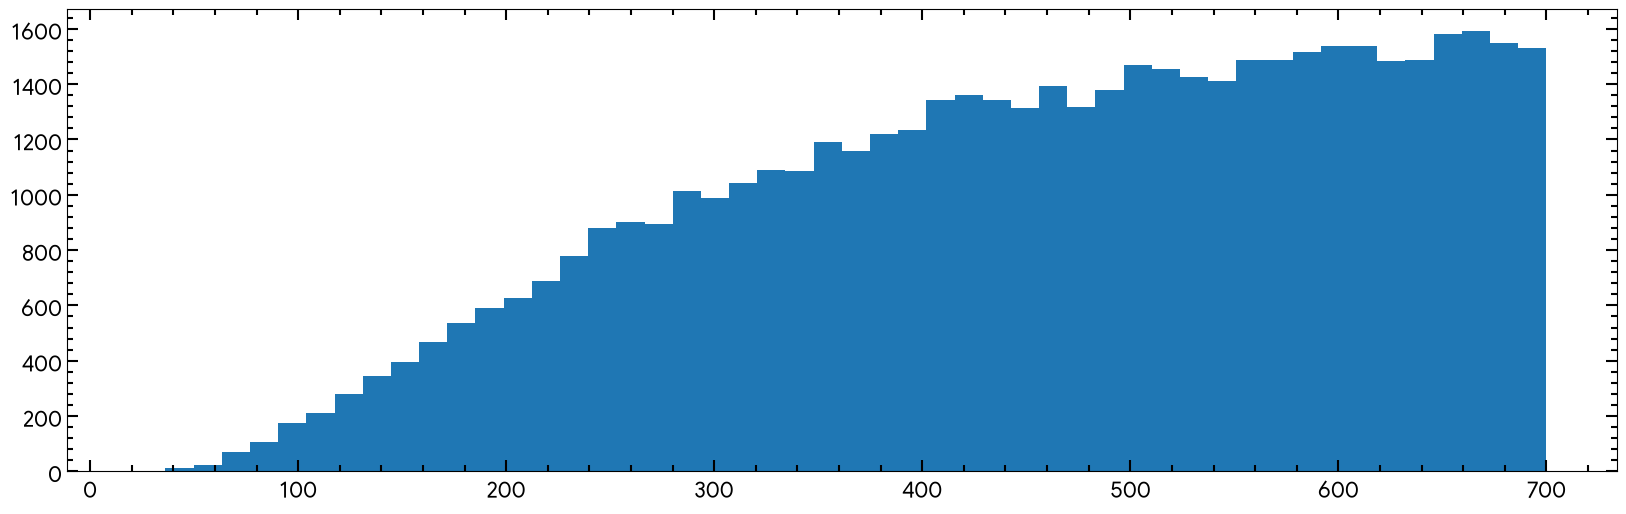

In [23]:
fig, ax = plt.subplots(figsize=(20, 6))

x = 1000 / df.parallax
ax.hist(x, bins=50)
plt.show()

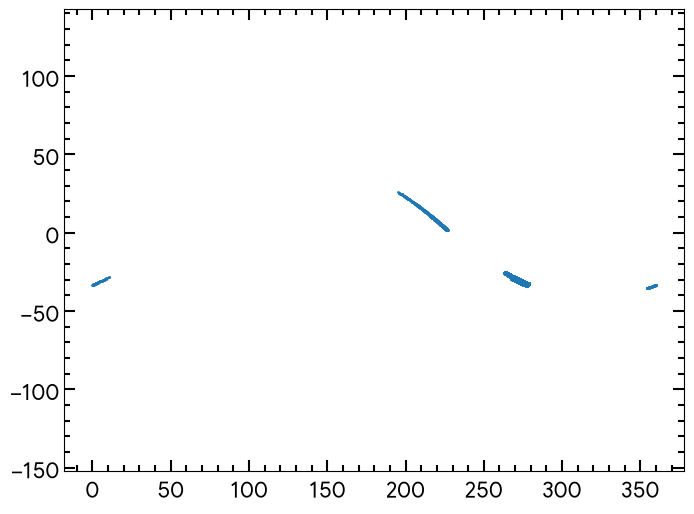

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

x = df.ra
y = df.dec

ax.scatter(x, y, s=1)

ax.set_aspect("equal", adjustable="datalim")
plt.show()

2.777777777777778e-07

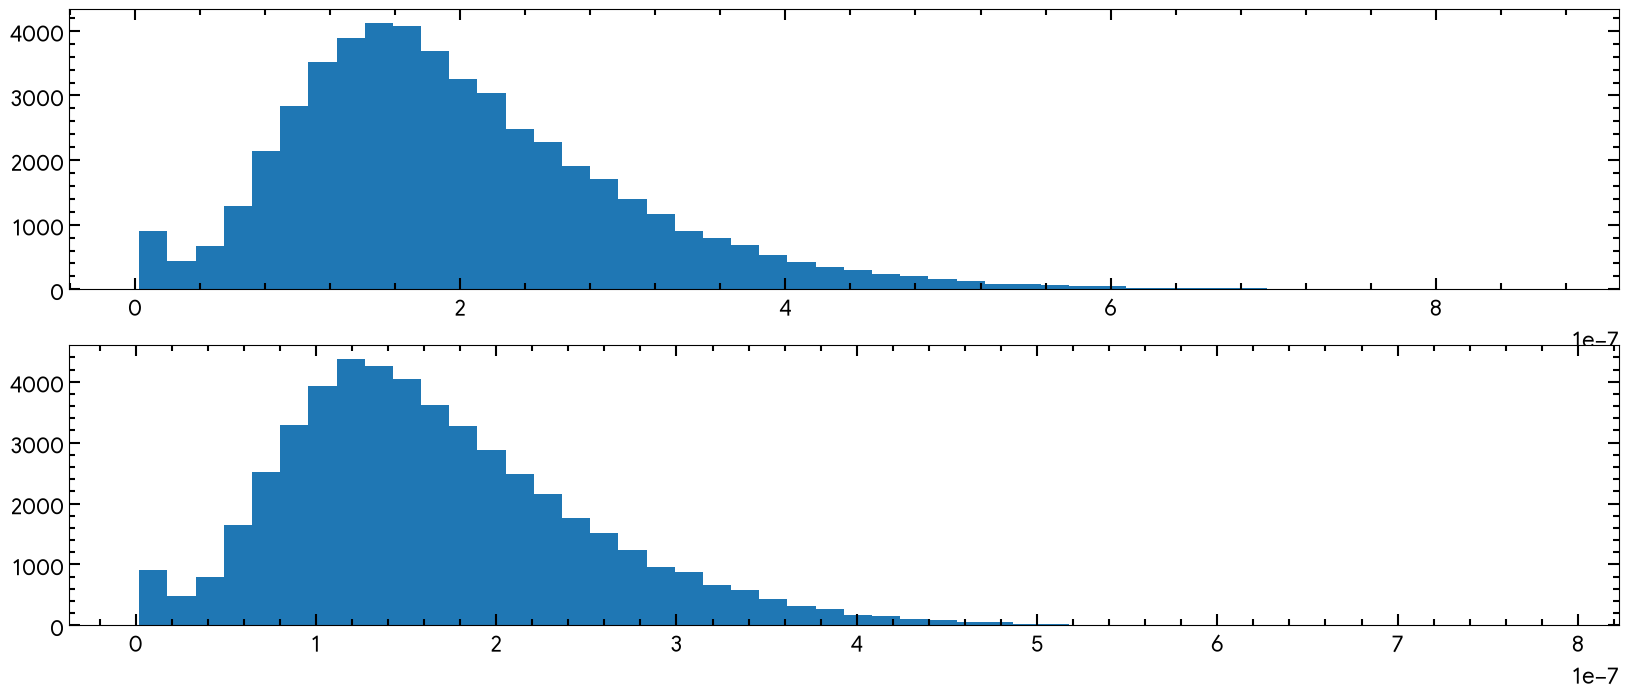

In [28]:
fig, ax = plt.subplots(2, 1, figsize=(20, 8))

x = df.ra_error.values * u.mas.to(u.deg)
ax[0].hist(x, bins=50)

x = df.dec_error.values * u.mas.to(u.deg)
ax[1].hist(x, bins=50)
plt.show()

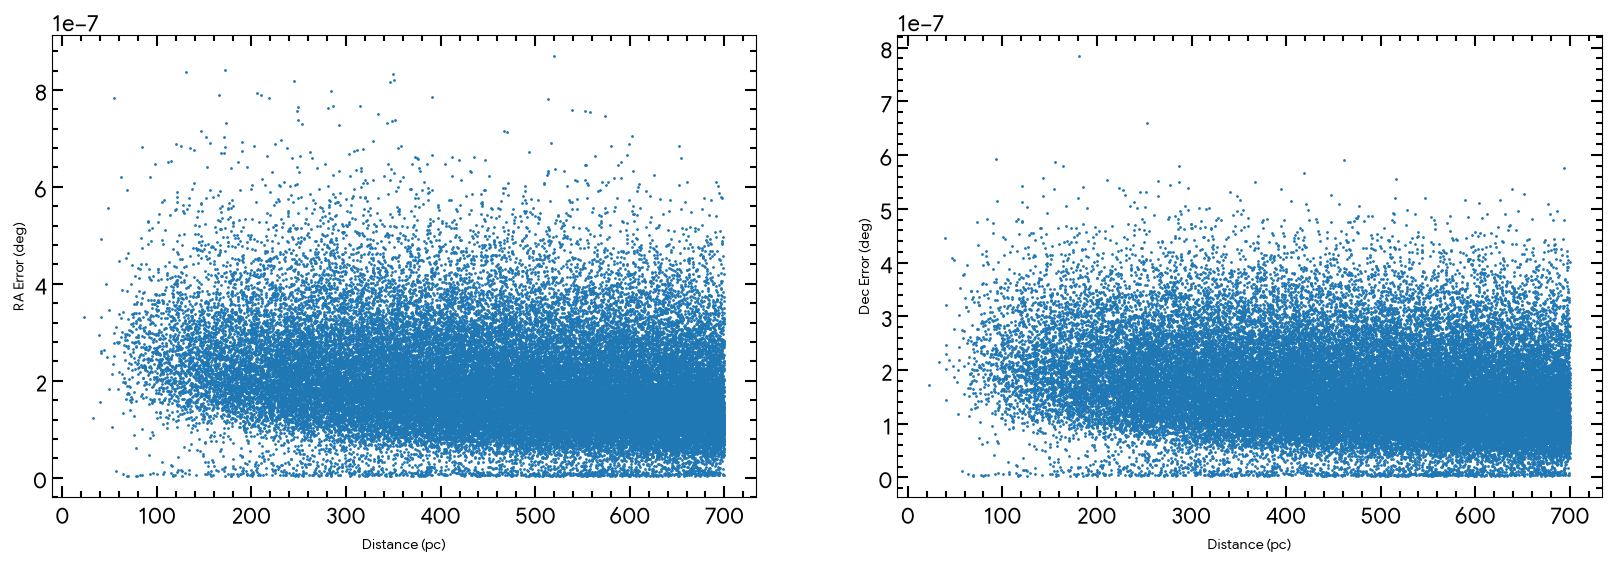

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

x = 1000 / df.parallax
y1 = df.ra_error.values * u.mas.to(u.deg)
y2 = df.dec_error.values * u.mas.to(u.deg)

ax[0].scatter(x, y1, s=1)
ax[1].scatter(x, y2, s=1)

ax[0].set_xlabel("Distance (pc)")
ax[0].set_ylabel("RA Error (deg)")
ax[1].set_xlabel("Distance (pc)")
ax[1].set_ylabel("Dec Error (deg)")
plt.show()

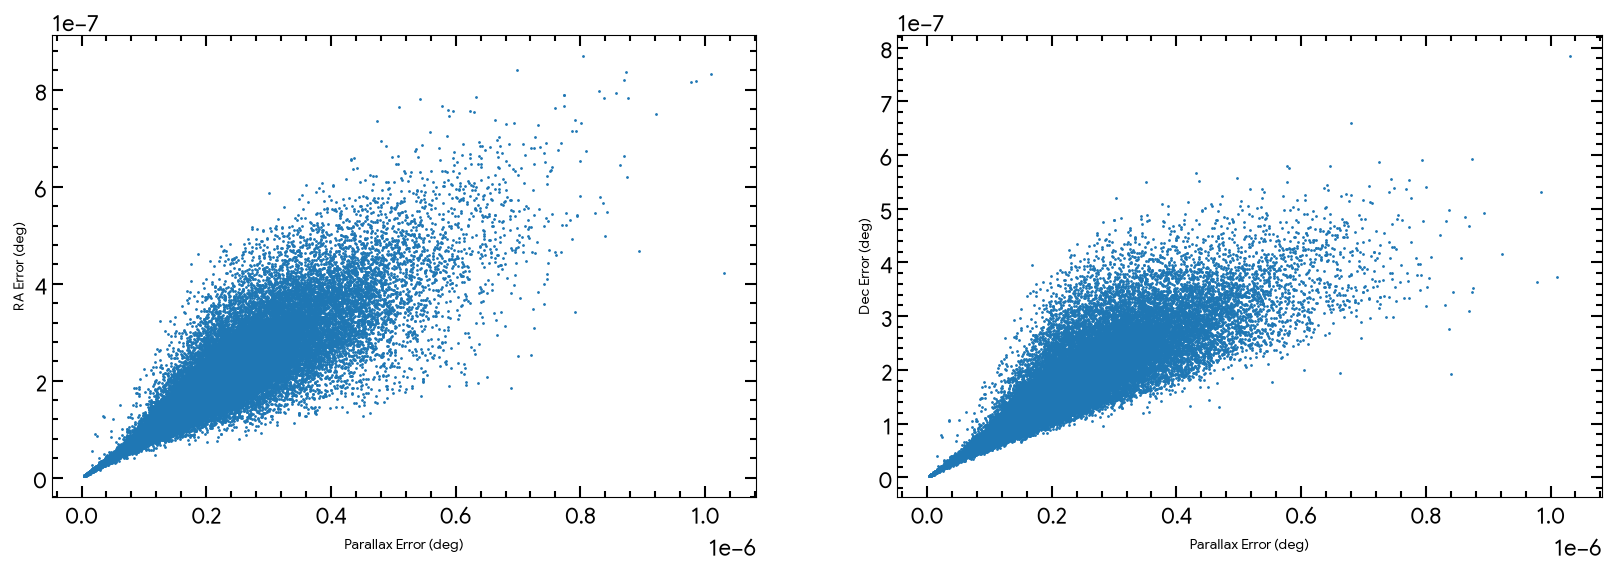

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

x = df.parallax_error * u.mas.to(u.deg)
y1 = df.ra_error.values * u.mas.to(u.deg)
y2 = df.dec_error.values * u.mas.to(u.deg)

ax[0].scatter(x, y1, s=1)
ax[1].scatter(x, y2, s=1)

ax[0].set_xlabel("Parallax Error (deg)")
ax[0].set_ylabel("RA Error (deg)")
ax[1].set_xlabel("Parallax Error (deg)")
ax[1].set_ylabel("Dec Error (deg)")
plt.show()

<Axes: >

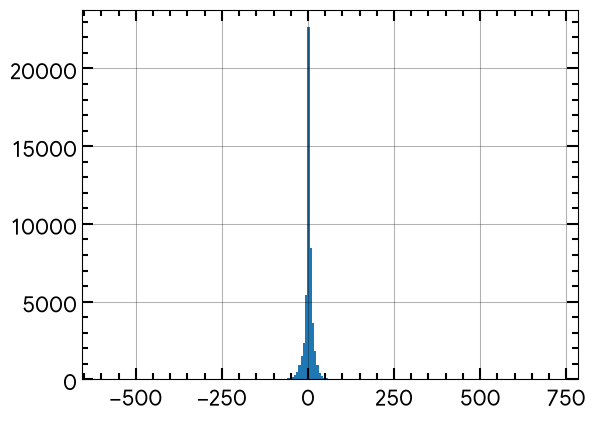

In [45]:
(
    df.parallax_error
    * (1000 / (df.parallax**2))
    * np.cos(df.dec * np.pi / 180)
    * np.cos(df.ra * np.pi / 180)
).hist(bins=200)